# Task 16 - Hypothesis Testing & A/B Testing

## Business Decision

Should passenger survival planning treat gender as a meaningful factor, or are observed survival differences due to random chance?

## Null Hypothesis (H0)

Male and female passengers have the same survival rate.

p_female = p_male

## Alternative Hypothesis (H1)

Female passengers have a higher survival rate than male passengers.

p_female > p_male

## Significance Level

α = 0.05

In [1]:
import pandas as pd
import numpy as np

from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.power import NormalIndPower

In [2]:
df = pd.read_csv("data/titanic_cleaned.csv")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,age_missing,family_size,is_alone,fare_per_person
0,False,3,male,22.0,1,0,7.2500,s,third,man,True,southampton,no,False,False,2,False,3.62500
1,True,1,female,38.0,1,0,71.2833,c,first,woman,False,cherbourg,yes,False,False,2,False,35.64165
2,True,3,female,26.0,0,0,7.9250,s,third,woman,False,southampton,yes,True,False,1,True,7.92500
3,True,1,female,35.0,1,0,53.1000,s,first,woman,False,southampton,yes,False,False,2,False,26.55000
4,False,3,male,35.0,0,0,8.0500,s,third,man,True,southampton,no,True,False,1,True,8.05000


In [3]:
female = df[df["sex"] == "female"]
male = df[df["sex"] == "male"]

female_survived = female["survived"].sum()
male_survived = male["survived"].sum()

female_total = len(female)
male_total = len(male)

print(f"Female survival rate: {female_survived/female_total:.3f}")
print(f"Male survival rate: {male_survived/male_total:.3f}")

Female survival rate: 0.739
Male survival rate: 0.216


In [4]:
effect_size = 0.3

power_analysis = NormalIndPower()

required_n = power_analysis.solve_power(
    effect_size=effect_size,
    power=0.80,
    alpha=0.05,
    ratio=1
)

print("Required sample size per group:", round(required_n))

Required sample size per group: 174


In [5]:
successes = np.array([
    female_survived,
    male_survived
])

observations = np.array([
    female_total,
    male_total
])

z_stat, p_value = proportions_ztest(
    successes,
    observations
)

print("Z Statistic:", z_stat)
print("P Value:", p_value)

Z Statistic: 14.369584413408107
P Value: 8.031171802351397e-47


In [6]:
female_ci = proportion_confint(
    female_survived,
    female_total,
    alpha=0.05
)

male_ci = proportion_confint(
    male_survived,
    male_total,
    alpha=0.05
)

print("Female 95% CI:", female_ci)
print("Male 95% CI:", male_ci)

Female 95% CI: (0.6883614606859441, 0.7893017695546058)
Male 95% CI: (0.17949367668743238, 0.252278217406254)


In [7]:
female_rate = female_survived / female_total
male_rate = male_survived / male_total

effect_size = female_rate - male_rate

print("Effect Size:", round(effect_size, 4))

Effect Size: 0.5229


In [8]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Reject H0


## Results

Female passengers had a survival rate of 73.9%, while male passengers had a survival rate of 21.6%.

A two-proportion z-test was conducted to determine whether the observed difference was statistically significant.

The test produced:

- Z Statistic = 14.37
- P Value = 8.03 × 10⁻⁴⁷

Since the p-value is much smaller than the significance level (α = 0.05), the null hypothesis is rejected.

The effect size was 0.5229, indicating that female passengers were approximately 52 percentage points more likely to survive than male passengers.

This represents a large and practically meaningful difference, not merely a statistically significant one.

## Recommendation

The analysis provides strong evidence that passenger gender had a significant impact on survival outcomes aboard the Titanic.

Because the observed effect is both statistically significant and practically large, gender should be considered an important explanatory variable in survival-related analyses.

Future investigations should evaluate how gender interacts with passenger class, age, fare, and family size to better understand survival patterns.

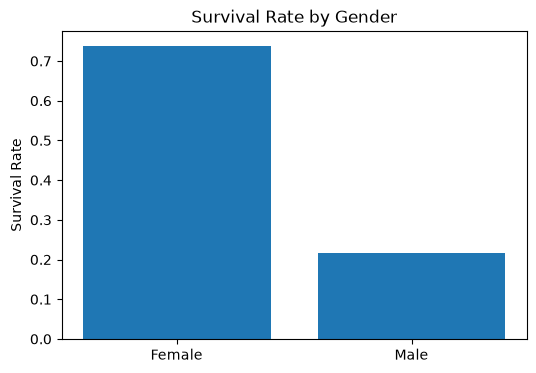

In [9]:
import matplotlib.pyplot as plt

rates = [female_rate, male_rate]
labels = ["Female", "Male"]

plt.figure(figsize=(6,4))
plt.bar(labels, rates)
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Gender")
plt.show()

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.power import TTestIndPower

# Load the cleaned Titanic dataset
df = pd.read_csv("data/titanic_cleaned.csv")

# Basic validation
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nSurvived distribution:")
print(df["survived"].value_counts(dropna=False))

print("\nSex distribution:")
print(df["sex"].value_counts(dropna=False))

Dataset shape: (782, 18)

Columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone', 'age_missing', 'family_size', 'is_alone', 'fare_per_person']

Missing values:
survived           0
pclass             0
sex                0
age                0
sibsp              0
parch              0
fare               0
embarked           0
class              0
who                0
adult_male         0
embark_town        0
alive              0
alone              0
age_missing        0
family_size        0
is_alone           0
fare_per_person    0
dtype: int64

Duplicate rows: 4

Survived distribution:
survived
False    461
True     321
Name: count, dtype: int64

Sex distribution:
sex
male      491
female    291
Name: count, dtype: int64


In [11]:
# Exact survival counts and rates
survival_counts = df["survived"].value_counts().sort_index()
survival_rates = df.groupby("survived").size() / len(df) * 100

print("Survival counts:")
print(survival_counts)

print("\nSurvival percentages:")
print(survival_rates.round(2))

Survival counts:
survived
False    461
True     321
Name: count, dtype: int64

Survival percentages:
survived
False    58.95
True     41.05
dtype: float64


In [12]:
# Day 16 — Hypothesis definition

alpha = 0.05

print("Decision question:")
print("Is passenger survival associated with sex in the cleaned Titanic dataset?")

print("\nNull hypothesis (H0):")
print("Female and male passengers have the same survival proportion.")

print("\nAlternative hypothesis (H1):")
print("Female and male passengers have different survival proportions.")

print("\nSignificance level (alpha):", alpha)
print("\nTest direction: Two-sided")

Decision question:
Is passenger survival associated with sex in the cleaned Titanic dataset?

Null hypothesis (H0):
Female and male passengers have the same survival proportion.

Alternative hypothesis (H1):
Female and male passengers have different survival proportions.

Significance level (alpha): 0.05

Test direction: Two-sided


In [13]:
# Compare the two groups before running the hypothesis test

group_summary = (
    df.groupby("sex")["survived"]
      .agg(
          sample_size="count",
          survived_count="sum",
          survival_rate="mean"
      )
      .reset_index()
)

group_summary["survival_rate"] = group_summary["survival_rate"] * 100

print(group_summary.to_string(index=False))

print("\nGroup-size check:")
print("Male sample size:", int(group_summary.loc[group_summary["sex"] == "male", "sample_size"].iloc[0]))
print("Female sample size:", int(group_summary.loc[group_summary["sex"] == "female", "sample_size"].iloc[0]))

   sex  sample_size  survived_count  survival_rate
female          291             215      73.883162
  male          491             106      21.588595

Group-size check:
Male sample size: 491
Female sample size: 291


In [14]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Observed survival proportions
female_rate = 215 / 291
male_rate = 106 / 491

# Effect size for comparing two independent proportions
effect_size = proportion_effectsize(female_rate, male_rate)

# Sample-size calculation
power_analysis = NormalIndPower()

required_n_per_group = power_analysis.solve_power(
    effect_size=abs(effect_size),
    alpha=alpha,
    power=0.80,
    ratio=1.0,
    alternative="two-sided"
)

print("Planned test: Two-proportion z-test")
print("Significance level (alpha):", alpha)
print("Target power:", 0.80)

print("\nObserved female survival rate:", round(female_rate * 100, 2), "%")
print("Observed male survival rate:", round(male_rate * 100, 2), "%")
print("Observed absolute difference:",
      round((female_rate - male_rate) * 100, 2), "percentage points")

print("\nStandardized proportion effect size:",
      round(abs(effect_size), 4))

print("\nRequired sample size per group:",
      round(required_n_per_group))

print("\nActual female sample size:", 291)
print("Actual male sample size:", 491)

Planned test: Two-proportion z-test
Significance level (alpha): 0.05
Target power: 0.8

Observed female survival rate: 73.88 %
Observed male survival rate: 21.59 %
Observed absolute difference: 52.29 percentage points

Standardized proportion effect size: 1.1023

Required sample size per group: 13

Actual female sample size: 291
Actual male sample size: 491


In [15]:
from statsmodels.stats.proportion import proportions_ztest

# Successes and sample sizes
successes = np.array([215, 106])   # female, male
sample_sizes = np.array([291, 491])

# Two-sided two-proportion z-test
z_stat, p_value = proportions_ztest(
    count=successes,
    nobs=sample_sizes,
    alternative="two-sided"
)

print("Two-proportion z-test")
print("----------------------")
print("Z-statistic:", round(z_stat, 4))
print("P-value:", p_value)
print("Alpha:", alpha)

if p_value < alpha:
    print("\nDecision: Reject H0")
    print("Interpretation: The difference in survival proportions is statistically significant.")
else:
    print("\nDecision: Fail to reject H0")
    print("Interpretation: There is insufficient evidence of a difference in survival proportions.")

Two-proportion z-test
----------------------
Z-statistic: 14.3696
P-value: 8.031171802351397e-47
Alpha: 0.05

Decision: Reject H0
Interpretation: The difference in survival proportions is statistically significant.


In [16]:
# Effect size and 95% confidence interval
# Difference is calculated as female survival rate - male survival rate

female_rate = successes[0] / sample_sizes[0]
male_rate = successes[1] / sample_sizes[1]

risk_difference = female_rate - male_rate

# Standard error for the unpooled difference in proportions
se_difference = np.sqrt(
    (female_rate * (1 - female_rate) / sample_sizes[0]) +
    (male_rate * (1 - male_rate) / sample_sizes[1])
)

z_critical = stats.norm.ppf(0.975)

ci_lower = risk_difference - z_critical * se_difference
ci_upper = risk_difference + z_critical * se_difference

print("Effect size: Difference in survival proportions")
print("-----------------------------------------------")
print("Female survival rate:", round(female_rate * 100, 2), "%")
print("Male survival rate:", round(male_rate * 100, 2), "%")
print("Absolute difference:", round(risk_difference * 100, 2), "percentage points")

print("\n95% Confidence Interval")
print("-----------------------")
print("Lower bound:", round(ci_lower * 100, 2), "percentage points")
print("Upper bound:", round(ci_upper * 100, 2), "percentage points")

print("\nInterpretation:")
print(
    f"We estimate that the female survival rate was "
    f"{risk_difference * 100:.2f} percentage points higher than the male "
    f"survival rate, with a 95% confidence interval from "
    f"{ci_lower * 100:.2f} to {ci_upper * 100:.2f} percentage points."
)

Effect size: Difference in survival proportions
-----------------------------------------------
Female survival rate: 73.88 %
Male survival rate: 21.59 %
Absolute difference: 52.29 percentage points

95% Confidence Interval
-----------------------
Lower bound: 46.07 percentage points
Upper bound: 58.52 percentage points

Interpretation:
We estimate that the female survival rate was 52.29 percentage points higher than the male survival rate, with a 95% confidence interval from 46.07 to 58.52 percentage points.


In [17]:
# Final statistical result summary

result = pd.DataFrame({
    "Metric": [
        "Female sample size",
        "Male sample size",
        "Female survival rate",
        "Male survival rate",
        "Absolute difference",
        "95% CI lower",
        "95% CI upper",
        "Z-statistic",
        "P-value",
        "Significance level"
    ],
    "Value": [
        sample_sizes[0],
        sample_sizes[1],
        f"{female_rate * 100:.2f}%",
        f"{male_rate * 100:.2f}%",
        f"{risk_difference * 100:.2f} percentage points",
        f"{ci_lower * 100:.2f} percentage points",
        f"{ci_upper * 100:.2f} percentage points",
        f"{z_stat:.4f}",
        f"{p_value:.4e}",
        alpha
    ]
})

print(result.to_string(index=False))

              Metric                   Value
  Female sample size                     291
    Male sample size                     491
Female survival rate                  73.88%
  Male survival rate                  21.59%
 Absolute difference 52.29 percentage points
        95% CI lower 46.07 percentage points
        95% CI upper 58.52 percentage points
         Z-statistic                 14.3696
             P-value              8.0312e-47
  Significance level                    0.05


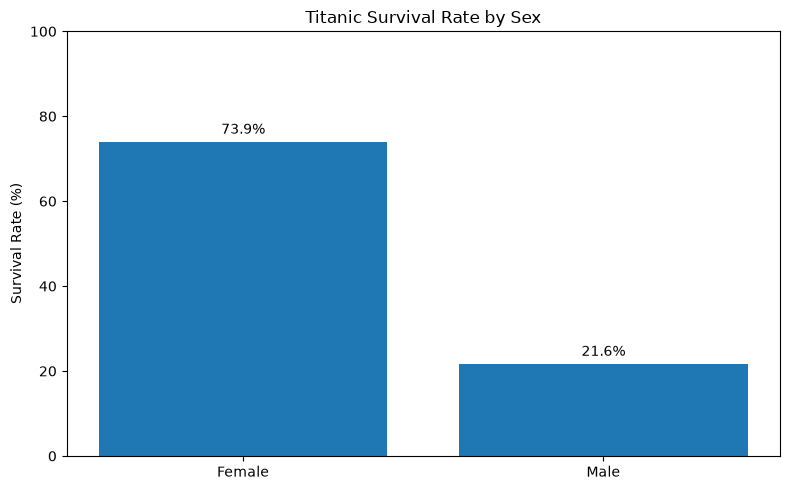

In [18]:
import matplotlib.pyplot as plt

# Prepare plotting data
plot_data = pd.DataFrame({
    "Sex": ["Female", "Male"],
    "Survival Rate": [female_rate * 100, male_rate * 100]
})

# Bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(plot_data["Sex"], plot_data["Survival Rate"])

plt.title("Titanic Survival Rate by Sex")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)

# Add percentage labels
for bar, value in zip(bars, plot_data["Survival Rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

## Recommendation

The two-proportion z-test found a statistically significant difference in survival
between female and male passengers (z = 14.3696, p = 8.03e-47). Female passengers
had a survival rate of 73.88%, compared with 21.59% for male passengers, an absolute
difference of 52.29 percentage points. The 95% confidence interval for the difference
was 46.07 to 58.52 percentage points.

The evidence supports rejecting the null hypothesis that female and male passengers
had equal survival proportions in this dataset. The effect is not only statistically
significant but also practically large. However, this is an observational analysis
of Titanic passenger data, not a randomized A/B experiment, so the result should be
interpreted as an association rather than proof that sex itself caused the difference
in survival.

# Day 16 — Hypothesis Testing & A/B Tests

## Objective

Determine whether passenger survival proportions differ significantly between
female and male passengers in the cleaned Titanic dataset.

## Decision Question

Is passenger survival associated with sex in the cleaned Titanic dataset?

## Hypotheses

**Null hypothesis (H₀):** Female and male passengers have the same survival proportion.

**Alternative hypothesis (H₁):** Female and male passengers have different survival proportions.

## Test Plan

- Dataset: `data/titanic_cleaned.csv`
- Observations: 782 passengers
- Outcome: `survived` (binary)
- Groups: female vs. male
- Statistical test: two-proportion z-test
- Significance level: α = 0.05
- Test direction: two-sided
- Target power for planning: 80%

## Why This Test?

The outcome is binary (survived / did not survive) and the comparison is between
two independent groups. A two-proportion z-test is therefore appropriate for
testing whether the observed survival proportions differ.

## Important Limitation

This analysis uses historical observational Titanic data. It is not a randomized
A/B experiment, so a statistically significant result demonstrates an association
between sex and survival in this dataset, not a causal effect of sex on survival.

In [3]:
# Data-quality and comparability checks before hypothesis testing

required_columns = {"sex", "survived"}
assert required_columns.issubset(df.columns), "Required columns are missing."

# Outcome must be binary
assert set(df["survived"].unique()).issubset({False, True}), \
    "The survived column contains unexpected values."

# Check the two comparison groups
group_counts = df["sex"].value_counts()

assert set(group_counts.index) == {"female", "male"}, \
    "Unexpected sex groups found."

assert group_counts["female"] > 0 and group_counts["male"] > 0, \
    "One or more comparison groups are empty."

# Confirm no missing values in variables used for the test
assert df[["sex", "survived"]].isna().sum().sum() == 0, \
    "Missing values found in test variables."

print("Data-quality checks: PASSED")
print("Total observations:", len(df))
print("Female observations:", group_counts["female"])
print("Male observations:", group_counts["male"])
print("Missing values in test variables:", df[["sex", "survived"]].isna().sum().sum())
print("Unique outcome values:", sorted(df["survived"].unique()))
print("Duplicate rows retained for analysis:", df.duplicated().sum())

Data-quality checks: PASSED
Total observations: 782
Female observations: 291
Male observations: 491
Missing values in test variables: 0
Unique outcome values: [np.False_, np.True_]
Duplicate rows retained for analysis: 4
